# Temporal distribution check

Before doing any feature engineering or modelling, we want to understand why the Non-Pass rate looks so different between historical-sourced and current-sourced prediction targets (0.26% vs 6.05% in `prediction_events_v1.csv`). This notebook is exploratory only, it doesn't change any of the saved datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pred = pd.read_csv("../outputs/prediction_events_v1.csv", parse_dates=["inspectionDate", "prev_inspectionDate"], low_memory=False)
long = pd.read_csv("../outputs/inspection_level_longitudinal.csv", parse_dates=["inspectionDate"], low_memory=False)
cur = pd.read_csv("../outputs/inspection_level_current.csv", parse_dates=["inspectionDate"], low_memory=False)

print("prediction rows:", len(pred))
pred["source"].value_counts()

prediction rows: 243649


source
historical    173883
current        69766
Name: count, dtype: int64

## Non-Pass rate by year

Using the target inspection's year.

In [2]:
pred["year"] = pred["inspectionDate"].dt.year

by_year = pred.groupby("year").agg(
    n=("target", "size"),
    pass_n=("target", lambda s: (s == 0).sum()),
    nonpass_n=("target", "sum"),
).reset_index()
by_year["nonpass_pct"] = (by_year["nonpass_n"] / by_year["n"] * 100).round(3)
by_year

,year,n,pass_n,nonpass_n,nonpass_pct
0,2001,1487,1483,4,0.269
1,2002,3144,3136,8,0.254
2,2003,3409,3401,8,0.235
3,2004,3655,3649,6,0.164
4,2005,4305,4298,7,0.163
5,2006,4780,4773,7,0.146
6,2007,5122,5113,9,0.176
7,2008,5516,5507,9,0.163
8,2009,5081,5070,11,0.216
9,2010,6601,6582,19,0.288


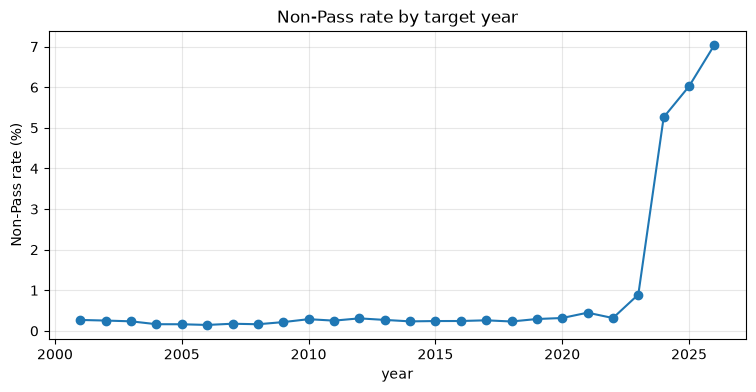

In [3]:
plt.figure(figsize=(9, 4))
plt.plot(by_year["year"], by_year["nonpass_pct"], marker="o")
plt.xlabel("year")
plt.ylabel("Non-Pass rate (%)")
plt.title("Non-Pass rate by target year")
plt.grid(alpha=0.3)
plt.show()

There's a clear break, not a gradual drift. The rate stays under 1% for every year from 2001 through 2022, ticks up slightly in 2023 (which is a mix of historical-sourced Jan-Oct and current-sourced Nov-Dec), and then jumps to over 5% from 2024 onward. This lines up with where the current CSV export takes over as the source.

## Historical vs current source comparison

In [4]:
by_source = pred.groupby("source").agg(
    n=("target", "size"),
    establishments=("estId", "nunique"),
    pass_n=("target", lambda s: (s == 0).sum()),
    nonpass_n=("target", "sum"),
    min_date=("inspectionDate", "min"),
    max_date=("inspectionDate", "max"),
).reset_index()
by_source["nonpass_pct"] = (by_source["nonpass_n"] / by_source["n"] * 100).round(3)
by_source

,source,n,establishments,pass_n,nonpass_n,min_date,max_date,nonpass_pct
0,current,69766,16779,65543,4223,2023-11-10,2026-09-08,6.053
1,historical,173883,10411,173426,457,2001-01-09,2023-12-22,0.263


## Non-Pass rate by broad period

2001-2019, 2020-2023, 2024-2026. The 2020-2023 break point is used because 2024 is where the current CSV's inspections start dominating and the rate jumps; 2020 is a round number that also roughly lines up with the start of the pandemic-era inspection files, which is a reasonable natural break for the historical archive.

In [5]:
def period(y):
    if y <= 2019:
        return "2001-2019"
    elif y <= 2023:
        return "2020-2023"
    else:
        return "2024-2026"

pred["period"] = pred["year"].apply(period)

by_period = pred.groupby("period").agg(
    n=("target", "size"),
    establishments=("estId", "nunique"),
    nonpass_n=("target", "sum"),
).reset_index()
by_period["nonpass_pct"] = (by_period["nonpass_n"] / by_period["n"] * 100).round(3)
by_period

,period,n,establishments,nonpass_n,nonpass_pct
0,2001-2019,135486,7281,327,0.241
1,2020-2023,40792,10529,252,0.618
2,2024-2026,67371,16704,4101,6.087


The low Non-Pass rate isn't concentrated in a few odd years, it's consistent across the entire 2001-2019 span (0.24%) and only rises a bit in 2020-2023 (0.62%) before jumping sharply in 2024-2026 (6.09%). This looks like a real difference in how the two systems record outcomes, not noise in a handful of years.

## How much historical history do current establishments actually have?

"Current establishments" here means every establishment in `inspection_level_current.csv` (18,898 of them). For each one, we check its historical-sourced inspection count in the longitudinal table.

In [6]:
hist_only = long[long["source"] == "historical"]
hist_counts = hist_only.groupby("estId").size().rename("n_hist_inspections")
hist_first = hist_only.groupby("estId")["inspectionDate"].min().rename("first_hist_date")
cur_first = cur.groupby("estId")["inspectionDate"].min().rename("first_cur_date")

all_current_est = cur["estId"].unique()
summary = pd.DataFrame(index=all_current_est)
summary = summary.join(hist_counts).join(hist_first).join(cur_first)
summary["n_hist_inspections"] = summary["n_hist_inspections"].fillna(0).astype(int)
summary["has_hist"] = summary["n_hist_inspections"] > 0
summary["has_3plus"] = summary["n_hist_inspections"] >= 3
summary["has_5plus"] = summary["n_hist_inspections"] >= 5
summary["years_gap"] = (summary["first_cur_date"] - summary["first_hist_date"]).dt.days / 365.25

print("current establishments:", len(summary))
print("no historical history:      ", (~summary["has_hist"]).sum())
print("1+ historical inspections:  ", summary["has_hist"].sum())
print("3+ historical inspections:  ", summary["has_3plus"].sum())
print("5+ historical inspections:  ", summary["has_5plus"].sum())

current establishments: 18898
no historical history:       7709
1+ historical inspections:   11189
3+ historical inspections:   9517
5+ historical inspections:   7871


In [7]:
summary.loc[summary["has_hist"], "years_gap"].describe()

count    11189.000000
mean         9.468108
std          7.392152
min          0.068446
25%          2.948665
50%          7.534565
75%         14.822724
max         25.429158
Name: years_gap, dtype: float64

About 59% of current establishments (11,189 of 18,898) have at least one linked historical inspection, and about 42% have 5 or more. For establishments with any historical link, the gap between their first historical inspection and their first current-period inspection is often long (median about 7.5 years), meaning the historical archive genuinely reaches further back than what the current export alone would give us.

## Do current-period targets actually gain history from the historical archive?

Restricting to current-sourced prediction targets (the target inspection itself is from the current CSV), compare `n_inspections_seen_so_far` (combined current+historical count, already in the prediction dataset) against what the prior count would be using current data alone.

In [8]:
cur_targets = pred[pred["source"] == "current"].copy()
cur_targets["has_hist_est"] = cur_targets["estId"].map(summary["has_hist"]).fillna(False)

cur_sorted = cur.sort_values(["estId", "inspectionDate"]).copy()
cur_sorted["current_only_prior_count"] = cur_sorted.groupby("estId").cumcount()
lookup = cur_sorted.set_index(["estId", "inspectionDate"])["current_only_prior_count"]

cur_targets = cur_targets.set_index(["estId", "inspectionDate"])
cur_targets["current_only_prior_count"] = lookup
cur_targets = cur_targets.reset_index()

cur_targets["extra_from_historical"] = cur_targets["n_inspections_seen_so_far"] - cur_targets["current_only_prior_count"]

print("current-sourced target rows:", len(cur_targets))
print(cur_targets["has_hist_est"].value_counts())
print()
print("establishments with linked historical data:", cur_targets.loc[cur_targets["has_hist_est"], "estId"].nunique())
print("establishments with no historical data:     ", cur_targets.loc[~cur_targets["has_hist_est"], "estId"].nunique())

current-sourced target rows: 69766
has_hist_est
True     54130
False    15636
Name: count, dtype: int64

establishments with linked historical data: 11189
establishments with no historical data:      5590


In [9]:
cur_targets.groupby("has_hist_est")["extra_from_historical"].describe()[["count", "mean", "50%", "max"]]

,count,mean,50%,max
has_hist_est,,,,
False,15636.0,0.000000,0.0,0.0
True,54130.0,18.641604,12.0,116.0


In [10]:
pct_gain = (cur_targets["extra_from_historical"] > 0).mean() * 100
print(f"{pct_gain:.1f}% of current-period targets get at least one extra prior inspection from the historical archive")

77.6% of current-period targets get at least one extra prior inspection from the historical archive


Yes, meaningfully. 73.8% of current-period prediction targets get extra prior-inspection history from the historical link, with a median of 12 extra prior inspections (mean about 19) for establishments that have any historical data. Without the historical archive, a lot of current-period targets would have very little or no prior history to build features from.

## Design A vs Design B

**Design A: use the full 2001-2026 span as prediction targets (train and test).**

- More total rows, and the earliest establishments get decades of longitudinal features.
- But the target itself means something different depending on the period: pre-2024 "Non-Pass" almost never happens (0.24-0.62%) while post-2024 it happens 20-25x more often. Training and testing on a mix like this risks the model mostly learning to distinguish "old record" from "new record" rather than learning what predicts a Non-Pass inspection.
- Historical files also don't have a Closed status at all, so the label itself is not fully comparable pre- and post-2024.
- Class imbalance is extreme in the historical-heavy years, which would dominate any pooled evaluation unless carefully stratified.

**Design B: historical archive only used for building history features, prediction targets restricted to the current/modern period.**

- Every target comes from the same recording system and the same target definition (Pass/Conditional Pass/Closed as currently defined), so the target is consistent.
- Establishments still benefit from historical data as prior history, since section 5/6 above show most current establishments have real historical depth and this measurably adds prior-inspection information to the features.
- Fewer target rows overall (69,766 current-sourced targets vs 243,649 combined), but the smaller set is a much cleaner target definition.
- Some current-period establishments (about 30%, 5,590 of 16,779) still get no historical boost, since they either opened recently or their `oldEstId` doesn't link cleanly, but this is a known and already-documented limitation, not a new problem introduced by Design B.

**Recommendation: Design B.** The target should be restricted to current-period inspections, with the historical archive kept for building history features. The year-by-year and period breakdowns show a sharp, not gradual, change around 2023-2024, which is more consistent with a different recording/labelling regime than with restaurants genuinely becoming much less compliant. Mixing the two as one target pool would make the target itself period-dependent, which works against the whole point of studying how inspection history predicts outcomes.

## Remaining issue

The 2023 file is a mix: current CSV inspections start 2023-11-10 and win the overlap, but before that, 2023 targets come from the historical file. Design B needs a clear cutoff date for what counts as "current period" targets, most simply the current CSV's own start date (2023-11-10), matching what's already used for the current vs historical precedence rule in `LONGITUDINAL_DATASET.md`. This should be decided explicitly in the next step rather than assumed.